In [1]:
import numpy as np
import pandas as pd
import re
import random
import contractions
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from keras.models import Model
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SimpleRNN, Input, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from functions import preprocess, export_weights, export_matrix_to_mem

# Importação e processamento do Dataset

In [2]:
df = pd.read_csv("IMDB Dataset.csv")

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
random_num = random.randrange(len(df))

sample_text = df.iloc[random_num]['review']
sample_text

"I actually liked certain things about this game. I loved the first person perspective and wish we had had that choice in the first three games. There's nothing like seeing the monsters up close, in your face. The graphics really weren't bad, but I would have liked more things to interact with even though it was just a shooter. The music was fine. The things I hated were: The movement kind of sucked and aiming was a total pain. The story was too lame for words and too much of the same old thing with no originality. The inability to save was awful!!! Some of us do have a life and would like to save to finish the game later. I thought the weapons kind of sucked, too. This game is fun for awhile, but it's nothing like the first three and only good if you just want to shoot stuff. I'd recommend it for the novelty of playing in the first person, but that's about it. Play it at your own risk."

In [5]:
print(preprocess(df.iloc[random_num]['review']))

actually liked certain thing game loved first person perspective wish choice first three game nothing like seeing monster close face graphic really bad would liked thing interact even though shooter music fine thing hated movement kind sucked aiming total pain story lame word much old thing originality inability save awful life would like save finish game later thought weapon kind sucked game fun awhile nothing like first three good want shoot stuff would recommend novelty playing first person play risk


In [6]:
df['review'] = df['review'].apply(preprocess)

In [7]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [8]:
n_words = [len(i.split(" ")) for i in df['review']]
print(f"Quantidade média de tokens {np.mean(n_words)}")
print(f"Mediana de tokens {np.median(n_words)}")

Quantidade média de tokens 116.49538
Mediana de tokens 86.0


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [10]:
vocab_size = 20000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

In [11]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [12]:
max_len = 120

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# LSTM

In [37]:
lstm_model = Sequential()

lstm_model.add(Input(shape=(max_len,)))

lstm_model.add(Embedding(input_dim=vocab_size, output_dim=4))
lstm_model.add(SpatialDropout1D(0.3))

lstm_model.add((LSTM(16, dropout=0.3)))

lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dropout(0.4))

lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

lstm_model.build(input_shape=(None, max_len))
lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 120, 4)         │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 120, 4)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 16)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,921 (320.00 KB)

 Trainable params: 81,921 (320.00 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

In [ ]:
"""lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=100,
    batch_size=128,   
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)"""

Epoch 1/100


250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5623 - loss: 0.6774 - val_accuracy: 0.8138 - val_loss: 0.5773 - learning_rate: 5.0000e-04
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8033 - loss: 0.4584 - val_accuracy: 0.8621 - val_loss: 0.3204 - learning_rate: 5.0000e-04
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8588 - loss: 0.3343 - val_accuracy: 0.8704 - val_loss: 0.3026 - learning_rate: 5.0000e-04
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8780 - loss: 0.2887 - val_accuracy: 0.8801 - val_loss: 0.2921 - learning_rate: 5.0000e-04
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8898 - loss: 0.2677 - val_accuracy: 0.8786 - val_loss: 0.3065 - learning_rate: 5.0000e-04


In [ ]:
#lstm_model.save_weights("lstm_modelo_pesado.weights.h5")

In [42]:

lstm_model.load_weights("lstm_modelo_pesado.weights.h5")

In [43]:
#Comentado por não ser acessário treinar rede novamente

""" plt.figure(figsize=(10,5))

plt.plot(lstm_history.history['accuracy'], label='Train Acc')
plt.plot(lstm_history.history['val_accuracy'], label='Val Acc')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()"""

' plt.figure(figsize=(10,5))\n\nplt.plot(lstm_history.history[\'accuracy\'], label=\'Train Acc\')\nplt.plot(lstm_history.history[\'val_accuracy\'], label=\'Val Acc\')\n\nplt.title("Model Accuracy")\nplt.xlabel("Epoch")\nplt.ylabel("Accuracy")\nplt.legend()\nplt.show()'

In [44]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8827 - loss: 0.2784
Test Accuracy: 0.8827000260353088


#### Acurácia de 0.80119

# Matriz de Confusão

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


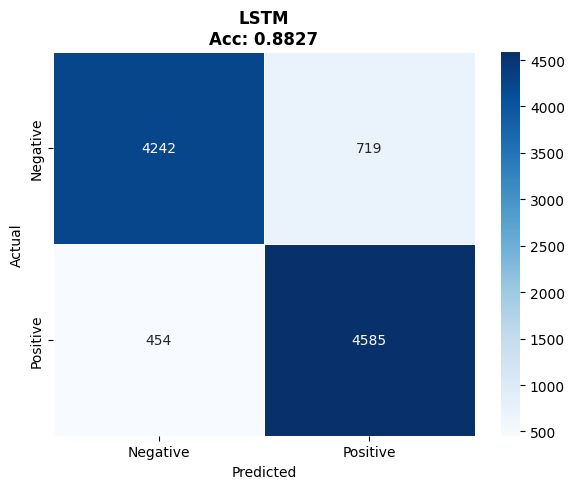

In [45]:
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    linewidths=0.5,
    linecolor='white'
)

acc = (y_pred_lstm == y_test.values).mean()

plt.title(f'LSTM\nAcc: {acc:.4f}', fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# Resultados da Classificação

In [46]:
for name, pred in zip(['LSTM'], [ y_pred_lstm]):
    print(f"{'='*45}")
    print(f"  {name} — Classification Report")
    print(f"{'='*45}")
    print(classification_report(y_test, pred, target_names=['Negative','Positive']))

  LSTM — Classification Report
              precision    recall  f1-score   support

    Negative       0.90      0.86      0.88      4961
    Positive       0.86      0.91      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



# Teste de Outputs


In [47]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)

x = X_test_pad[0].tolist()

outputs = inspection_model.predict(np.array([x]))

# salva em txt
with open("layer_outputs_simplified_model.txt", "w", encoding="utf-8") as f:

    for layer, output in zip(lstm_model.layers, outputs):

        f.write(f"\n{'='*60}\n")
        f.write(f"Camada: {layer.name}\n")
        f.write(f"Shape: {output.shape}\n")
        f.write(f"{'='*60}\n\n")

        # converte numpy array para string
        np.set_printoptions(threshold=np.inf)

        f.write(np.array2string(
            output,
            separator=', ',
            precision=6
        ))

        f.write("\n\n")

print("Outputs salvos em layer_outputs_Simplified_model.txt")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step
Outputs salvos em layer_outputs_Simplified_model.txt


In [48]:
lstm_model.get_state_tree()

{'trainable_variables': {'sequential_2': {'embedding_2': {'embeddings': <tf.Variable 'sequential_2/embedding_2/embeddings:0' shape=(20000, 4) dtype=float32, numpy=
    array([[-1.33376895e-03, -2.17920728e-03, -2.99974671e-03,
            -1.55000365e-03],
           [ 1.01920478e-02, -1.09109422e-02,  1.24013834e-02,
             1.40406778e-02],
           [ 2.75297905e-03,  2.67122290e-03,  1.01221297e-02,
             1.11959558e-02],
           [-1.19428439e-02,  1.49164125e-02,  4.59483825e-03,
             4.67015058e-03],
           [ 2.87263677e-03,  7.62740895e-03,  1.92188821e-03,
            -1.74217559e-02],
           [-2.08427105e-02,  3.21429875e-03,  6.63725007e-03,
            -1.18320873e-02],
           [-2.85274684e-02,  1.52176702e-02, -2.43641045e-02,
            -2.97987740e-02],
           [ 4.51202951e-02, -3.67516167e-02,  6.00197539e-02,
             4.44504358e-02],
           [-4.72953655e-02,  6.89334124e-02, -3.15492824e-02,
            -4.20882516e-02],

In [49]:
from functions import *

# Exportação de Pesos

In [50]:
export_weights(lstm_model, mode='lstm', output_file="../../../Geral Tests SystemVerilog/Q8_24/Simplified Neural Network/weights.mem")


print("\n" + "#"*60)
print("CONCLUIDO!")
print("#"*60)


MODO LSTM: Exportando pesos a partir da primeira LSTM
Ignorando: Embedding e SpatialDropout1D

Camada 0: LSTM
  addr=0x08000 Wx_input[0][0] = -0.242086
  addr=0x08001 Wx_input[0][1] = 0.156680
  addr=0x08080 Wx_input[1][0] = -0.276415
  addr=0x08081 Wx_input[1][1] = 0.164530
  addr=0x08040 Wh_input[0][0] = -0.094597
  addr=0x08041 Wh_input[0][1] = -0.026734
  addr=0x080C0 Wh_input[1][0] = -0.187087
  addr=0x080C1 Wh_input[1][1] = -0.067335
  addr=0x18000 bias_input[0] = 0.057688
  addr=0x18080 bias_input[1] = 0.044556
  addr=0x0A000 Wx_forget[0][0] = 0.061779
  addr=0x0A001 Wx_forget[0][1] = 0.263218
  addr=0x0A080 Wx_forget[1][0] = -0.325731
  addr=0x0A081 Wx_forget[1][1] = -0.056703
  addr=0x0A040 Wh_forget[0][0] = -0.124258
  addr=0x0A041 Wh_forget[0][1] = -0.093025
  addr=0x0A0C0 Wh_forget[1][0] = -0.108281
  addr=0x0A0C1 Wh_forget[1][1] = 0.039822
  addr=0x1A000 bias_forget[0] = 1.059142
  addr=0x1A080 bias_forget[1] = 1.034630
  addr=0x0C000 Wx_candidate[0][0] = 0.398070
  addr=

# Teste Global

In [51]:
FRAC = 24
SCALE = 1 << FRAC

INT32_MAX = np.int32(2**31 - 1)
INT32_MIN = np.int32(-(2**31))

def float_to_q24(val):
    if np.isnan(val):
        return np.int32(0)
    if np.isposinf(val):
        return INT32_MAX
    if np.isneginf(val):
        return INT32_MIN
    fixed = np.round(val * SCALE)
    return np.int32(fixed)


In [52]:
def export_matrix_to_mem(matrix,result,ground_result, output_file="matrix.mem"):
    mem = {}
    
    for linha_idx in range(matrix.shape[0]):
        for col_idx in range(4):
            addr = (linha_idx << 2) | col_idx
            valor = matrix[linha_idx, col_idx]
            valor_q24 = float_to_q24(valor)  # sua função original
            mem[addr] = valor_q24
    
    # ESCREVE EXATAMENTE COMO NO SEU CÓDIGO ORIGINAL
    with open(output_file, "w") as f:
        line = 0
        result_hex = float_to_q24(result)
        for addr in sorted(mem.keys()):
            val = np.int32(mem[addr])  # ← igual ao original
            if line == 0:
                f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X} {int(result_hex) & 0xFFFFFFFF:08X}  {int(ground_result) & 0xFFFFFFFF:01X}   \n")
            else:
                f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X}\n")
            line+=1
    print(f"Arquivo salvo: {output_file}")
    return mem

In [53]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)
#total = len(y_pred_lstm)
total = 30

valores_out_embbeding = []
valores_out_lstm = []
valores_out_relu = []
valores_out_sigmoid = []

for i in range(total):
    x = np.array([X_test_pad[i].tolist()])

    outputs = inspection_model.predict(x)
    
    export_matrix_to_mem(outputs[0][0], outputs[6][0][0], y_test.values[i], f"../../../Geral Tests SystemVerilog/Q8_24/Simplified Neural Network/Global Processing/dados_{i}.mem")

    valores_out_embbeding += outputs[0].reshape(-1).tolist()
    valores_out_lstm += outputs[2].reshape(-1).tolist()
    valores_out_relu += outputs[4].reshape(-1).tolist()
    valores_out_sigmoid += outputs[6].reshape(-1).tolist()

    print(f"{i} de {total}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24/Simplified Neural Network/Global Processing/dados_0.mem
0 de 30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24/Simplified Neural Network/Global Processing/dados_1.mem
1 de 30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24/Simplified Neural Network/Global Processing/dados_2.mem
2 de 30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24/Simplified Neural Network/Global Processing/dados_3.mem
3 de 30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24/Simplified Neural Network/Global Processing/dados_4.mem
4 de 30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24/Simplified Neural Network/Global Processing/dados_5.mem
5 de 30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Arquivo salvo

In [29]:
out_verilog=pd.read_csv("resultados_lstm.txt",skiprows=3,header=None,sep=" ")[12]
out_verilog 

0     0.426999
1     0.253196
2    -0.106051
3    -0.033208
4    -0.295246
        ...   
95   -0.126627
96   -0.230331
97   -0.193621
98    0.143159
99    0.091574
Name: 12, Length: 100, dtype: float64

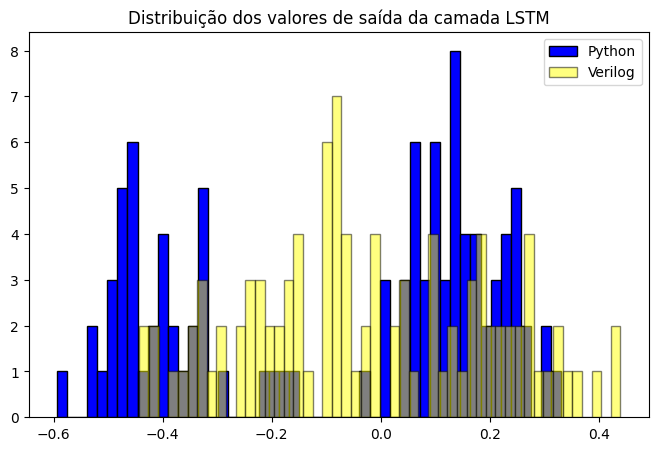

In [30]:
plt.figure(figsize=(8,5))

plt.hist(
    valores_out_lstm,
    bins=50,
    color=(0, 0, 1),
    alpha=1,
    edgecolor='black',
    label='Python'
)

plt.hist(
    out_verilog,
    bins=50,
    color='yellow',
    alpha=0.5,
    edgecolor='black',
    label='Verilog'
)

plt.title("Distribuição dos valores de saída da camada LSTM")
plt.legend()
plt.show()

R² = -1.551543


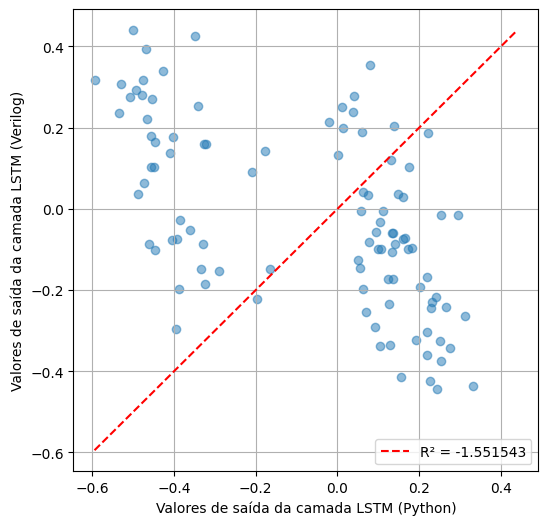

In [31]:

from sklearn.metrics import r2_score

plt.figure(figsize=(6,6))

plt.scatter(valores_out_lstm, out_verilog, alpha=0.5)

# reta y = x
lim_min = min(np.min(valores_out_lstm), np.min(out_verilog))
lim_max = max(np.max(valores_out_lstm), np.max(out_verilog))
r2 = r2_score(valores_out_lstm, out_verilog)
print(f"R² = {r2:.6f}")
plt.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', label=f'R² = {r2:.6f}')

# R²


plt.xlabel("Valores de saída da camada LSTM (Python)")
plt.ylabel("Valores de saída da camada LSTM (Verilog)")
plt.legend()
plt.grid(True)
plt.show()

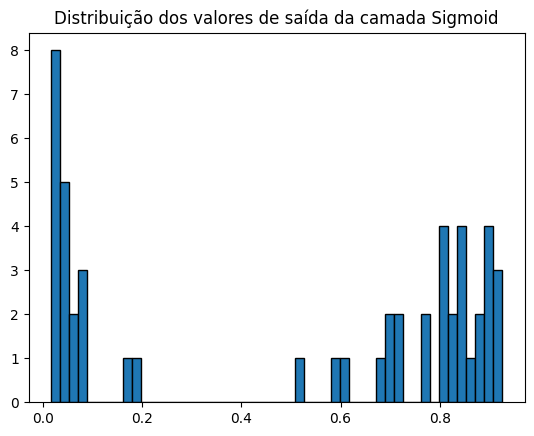

In [32]:
plt.title("Distribuição dos valores de saída da camada Sigmoid")
plt.hist(valores_out_sigmoid, bins=50, edgecolor='black')
plt.show()

In [33]:
dado = pd.read()

AttributeError: module 'pandas' has no attribute 'read'

In [ ]:
import numpy as np

# ============================================================
# CONSTANTES Q8.24
# ============================================================
FRAC = 24
SCALE = 1 << FRAC  # 2^24 = 16777216

def q24_to_float(q_val):
    """Converte Q8.24 para float32"""
    # Se for negativo (bit 31 = 1), faz o sinal
    if q_val >= 0x80000000:
        q_val = q_val - 0x100000000
    return q_val / SCALE

# ============================================================
# LEITURA SIMPLES DOS ARQUIVOS
# ============================================================
for i in range(1):
    arquivo = f"../../../Geral Tests SystemVerilog/Q8_24/Simplified Neural Network/Small Global Processing/dados_{i}.mem"
    
    try:
        with open(arquivo, "r") as f:
            linhas = f.readlines()
        
        # Pula linhas vazias
        linhas = [l.strip() for l in linhas if l.strip()]
        
        print(f"\nArquivo {i}: {len(linhas)} linhas")
        
        # Primeira linha (especial)
        primeira = linhas[0].split()
        if len(primeira) >= 4:
            addr = int(primeira[0], 16)
            data = int(primeira[1], 16)
            python_result = int(primeira[2], 16)
            gt = int(primeira[3], 16)
            
            print(f"  Python result: {q24_to_float(python_result):.6f}")
            print(f"  Ground truth: {gt}")
            print(f"  Primeiro dado: addr=0x{addr:05X}, data={q24_to_float(data):.6f}")
        
        # Mostra os primeiros 5 dados normais
        print(f"  Primeiros dados (Q8.24 -> float):")
        for j in range(1, min(6, len(linhas))):
            partes = linhas[j].split()
            if len(partes) >= 2:
                addr = int(partes[0], 16)
                data = int(partes[1], 16)
                print(f"    [{j}] addr=0x{addr:05X}, data={q24_to_float(data):.6f}")
        
    except FileNotFoundError:
        print(f"Arquivo {i} não encontrado")
        break
    except Exception as e:
        print(f"Erro no arquivo {i}: {e}")